INtegrantes: Juan Palomeque, Juan Pablo Alegre, Tomas Moretti


TP integrador de Analisis de Datos

In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
from datetime import datetime
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore', category=FutureWarning)

In [6]:
# Cargar el dataset
df = pd.read_csv('datasetecobici.csv')
print(f'Dataset cargado exitosamente')
print(f'Forma del dataset: {df.shape}')

Dataset cargado exitosamente
Forma del dataset: (3559284, 17)


In [7]:
# Información básica
n_observaciones = df.shape[0]
n_variables = df.shape[1]

print(f'{'='*60}')
print(f'✓ Observaciones: {n_observaciones:,}')
print(f'✓ Variables: {n_variables}')
print(f'{'='*60}')
print(f'\nColumnas del dataset:')
print(df.columns.tolist())


✓ Observaciones: 3,559,284
✓ Variables: 17

Columnas del dataset:
['id_recorrido', 'duracion_recorrido', 'fecha_origen_recorrido', 'id_estacion_origen', 'nombre_estacion_origen', 'direccion_estacion_origen', 'long_estacion_origen', 'lat_estacion_origen', 'fecha_destino_recorrido', 'id_estacion_destino', 'nombre_estacion_destino', 'direccion_estacion_destino', 'long_estacion_destino', 'lat_estacion_destino', 'id_usuario', 'modelo_bicicleta', 'genero']


In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3559284 entries, 0 to 3559283
Data columns (total 17 columns):
 #   Column                      Dtype  
---  ------                      -----  
 0   id_recorrido                int64  
 1   duracion_recorrido          int64  
 2   fecha_origen_recorrido      str    
 3   id_estacion_origen          int64  
 4   nombre_estacion_origen      str    
 5   direccion_estacion_origen   str    
 6   long_estacion_origen        float64
 7   lat_estacion_origen         float64
 8   fecha_destino_recorrido     str    
 9   id_estacion_destino         int64  
 10  nombre_estacion_destino     str    
 11  direccion_estacion_destino  str    
 12  long_estacion_destino       float64
 13  lat_estacion_destino        float64
 14  id_usuario                  float64
 15  modelo_bicicleta            str    
 16  genero                      str    
dtypes: float64(5), int64(4), str(8)
memory usage: 461.6 MB


In [14]:
# Estadísticas descriptivas
df[numeric_cols].describe().round(3)

,id_recorrido,duracion_recorrido,id_estacion_origen,long_estacion_origen,lat_estacion_origen,id_estacion_destino,long_estacion_destino,lat_estacion_destino,id_usuario
count,3.559284e+06,3559284.000,3559284.000,3559284.000,3559284.000,3559284.00,3559284.000,3559284.000,3559284.000
mean,2.234123e+07,1274.827,235.606,-58.423,-34.599,237.15,-58.423,-34.599,790885.096
std,1.257090e+06,9584.216,165.799,0.038,0.024,165.71,0.038,0.025,388216.941
min,2.018097e+07,0.000,2.000,-58.527,-34.688,2.00,-58.527,-34.688,24.000
25%,2.123850e+07,493.000,93.000,-58.450,-34.616,96.00,-58.450,-34.616,511824.000
50%,2.235117e+07,881.000,199.000,-58.421,-34.601,200.00,-58.421,-34.601,913360.000
75%,2.343694e+07,1474.000,378.000,-58.394,-34.583,379.00,-58.394,-34.582,1113537.000
max,2.450328e+07,2571165.000,577.000,-58.355,-34.537,577.00,-58.355,-34.537,1280599.000


In [16]:
df.head()

,id_recorrido,duracion_recorrido,fecha_origen_recorrido,id_estacion_origen,nombre_estacion_origen,direccion_estacion_origen,long_estacion_origen,lat_estacion_origen,fecha_destino_recorrido,id_estacion_destino,nombre_estacion_destino,direccion_estacion_destino,long_estacion_destino,lat_estacion_destino,id_usuario,modelo_bicicleta,genero
0,20428222,568,2024-01-23 18:36:00,513,308 - SAN MARTIN II,Av. San Martín 5129,-58.490739,-34.597130,2024-01-23 18:45:28,498,055 - HABANA,Gral. José Gervasio Artigas 4298 (y Habana),-58.494959,-34.586598,992557.0,FIT,MALE
1,20431744,1355,2024-01-23 22:41:20,460,133 - BEIRO Y SEGUROLA,Segurola 3194,-58.511930,-34.607500,2024-01-23 23:03:55,382,204 - Biarritz,Biarritz 2403,-58.477255,-34.605431,320782.0,FIT,FEMALE
2,20429936,0,2024-01-23 20:06:22,467,328 - SARMIENTO II,Sarmiento 2037,-58.395893,-34.605514,2024-01-23 20:06:22,6,006 - Parque Lezama,"Avenida Martin Garcia, 295",-58.369758,-34.628526,828678.0,FIT,FEMALE
3,20429976,0,2024-01-23 20:08:17,382,204 - Biarritz,Biarritz 2403,-58.477255,-34.605431,2024-01-23 20:08:17,460,133 - BEIRO Y SEGUROLA,Segurola 3194,-58.511930,-34.607500,320782.0,ICONIC,FEMALE
4,20424802,680,2024-01-23 15:18:39,137,137 - AZOPARDO Y CHILE,AZOPARDO 700,-58.367492,-34.615598,2024-01-23 15:29:59,150,150 - RODRIGO BUENO,Av. España 2200,-58.355465,-34.618755,861425.0,FIT,FEMALE


In [18]:
df.nunique()

id_recorrido                  3559283
duracion_recorrido              19543
fecha_origen_recorrido        3227772
id_estacion_origen                395
nombre_estacion_origen            395
direccion_estacion_origen         393
long_estacion_origen              395
lat_estacion_origen               395
fecha_destino_recorrido       3220154
id_estacion_destino               398
nombre_estacion_destino           398
direccion_estacion_destino        395
long_estacion_destino             397
lat_estacion_destino              397
id_usuario                     262673
modelo_bicicleta                    2
genero                              3
dtype: int64

Cambiar fecha a un tipo correcto. DT
estacion origen faltan 2 direcciones 
estacion destino faltan 3 direcciones.


In [23]:
#DAtos nulos o vacios. ND.
df.isnull().sum()

id_recorrido                      0
duracion_recorrido                0
fecha_origen_recorrido            0
id_estacion_origen                0
nombre_estacion_origen            0
direccion_estacion_origen         0
long_estacion_origen              0
lat_estacion_origen               0
fecha_destino_recorrido        3379
id_estacion_destino               0
nombre_estacion_destino           0
direccion_estacion_destino        0
long_estacion_destino             0
lat_estacion_destino              0
id_usuario                        0
modelo_bicicleta                  0
genero                        11946
dtype: int64

In [28]:
#duplicados
df[df.duplicated(keep=False)]

,id_recorrido,duracion_recorrido,fecha_origen_recorrido,id_estacion_origen,nombre_estacion_origen,direccion_estacion_origen,long_estacion_origen,lat_estacion_origen,fecha_destino_recorrido,id_estacion_destino,nombre_estacion_destino,direccion_estacion_destino,long_estacion_destino,lat_estacion_destino,id_usuario,modelo_bicicleta,genero
434350,22425357,1119,2024-07-23 12:30:30,104,104 - Federico Lacroze,Av. Guzman 1100 & Av. Corrientes,-58.455212,-34.587617,2024-07-23 12:49:09,402,-- CDO Chacarita -- (Temporal),3209 Av. Francisco Beiro,-58.498542,-34.597612,1039158.0,FIT,MALE
434351,22425357,1119,2024-07-23 12:30:30,104,104 - Federico Lacroze,Av. Guzman 1100 & Av. Corrientes,-58.455212,-34.587617,2024-07-23 12:49:09,402,-- CDO Chacarita -- (Temporal),3209 Av. Francisco Beiro,-58.498542,-34.597612,1039158.0,FIT,MALE


In [29]:
df[df['id_recorrido'].duplicated(keep=False)].sort_values('id_recorrido')

,id_recorrido,duracion_recorrido,fecha_origen_recorrido,id_estacion_origen,nombre_estacion_origen,direccion_estacion_origen,long_estacion_origen,lat_estacion_origen,fecha_destino_recorrido,id_estacion_destino,nombre_estacion_destino,direccion_estacion_destino,long_estacion_destino,lat_estacion_destino,id_usuario,modelo_bicicleta,genero
434350,22425357,1119,2024-07-23 12:30:30,104,104 - Federico Lacroze,Av. Guzman 1100 & Av. Corrientes,-58.455212,-34.587617,2024-07-23 12:49:09,402,-- CDO Chacarita -- (Temporal),3209 Av. Francisco Beiro,-58.498542,-34.597612,1039158.0,FIT,MALE
434351,22425357,1119,2024-07-23 12:30:30,104,104 - Federico Lacroze,Av. Guzman 1100 & Av. Corrientes,-58.455212,-34.587617,2024-07-23 12:49:09,402,-- CDO Chacarita -- (Temporal),3209 Av. Francisco Beiro,-58.498542,-34.597612,1039158.0,FIT,MALE


In [31]:
#Elimino uno de los duplicados.
df = df.drop_duplicates(subset='id_recorrido', keep='first')

In [32]:
df['id_recorrido'].duplicated().sum()   # tiene que dar 0

np.int64(0)

In [33]:
df.median(numeric_only=True)

id_recorrido             2.235117e+07
duracion_recorrido       8.810000e+02
id_estacion_origen       1.990000e+02
long_estacion_origen    -5.842095e+01
lat_estacion_origen     -3.460075e+01
id_estacion_destino      2.000000e+02
long_estacion_destino   -5.842095e+01
lat_estacion_destino    -3.460075e+01
id_usuario               9.133600e+05
dtype: float64

In [34]:
df.skew(numeric_only=True)

id_recorrido              -0.004623
duracion_recorrido       156.219506
id_estacion_origen         0.420942
long_estacion_origen      -0.340168
lat_estacion_origen        0.066669
id_estacion_destino        0.403996
long_estacion_destino     -0.331624
lat_estacion_destino       0.046576
id_usuario                -0.745927
dtype: float64

In [36]:
df.kurt(numeric_only=True)

id_recorrido                -1.225535
duracion_recorrido       30108.148798
id_estacion_origen          -1.081461
long_estacion_origen        -0.611996
lat_estacion_origen          0.010099
id_estacion_destino         -1.092853
long_estacion_destino       -0.623782
lat_estacion_destino        -0.011016
id_usuario                  -0.793902
dtype: float64

In [37]:
df.select_dtypes(include=np.number).head()

,id_recorrido,duracion_recorrido,id_estacion_origen,long_estacion_origen,lat_estacion_origen,id_estacion_destino,long_estacion_destino,lat_estacion_destino,id_usuario
0,20428222,568,513,-58.490739,-34.597130,498,-58.494959,-34.586598,992557.0
1,20431744,1355,460,-58.511930,-34.607500,382,-58.477255,-34.605431,320782.0
2,20429936,0,467,-58.395893,-34.605514,6,-58.369758,-34.628526,828678.0
3,20429976,0,382,-58.477255,-34.605431,460,-58.511930,-34.607500,320782.0
4,20424802,680,137,-58.367492,-34.615598,150,-58.355465,-34.618755,861425.0


/var/folders/b0/rjcwq48561q3hnwzmfnnzrrc0000gn/T/ipykernel_1774/399506197.py:13: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(df[columna], vert=False)


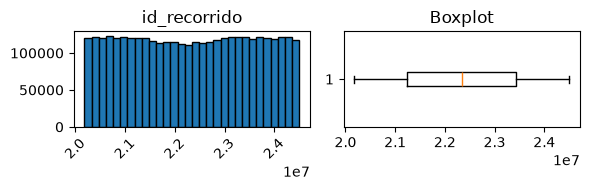

/var/folders/b0/rjcwq48561q3hnwzmfnnzrrc0000gn/T/ipykernel_1774/399506197.py:13: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(df[columna], vert=False)


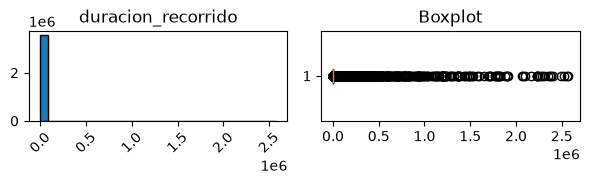

/var/folders/b0/rjcwq48561q3hnwzmfnnzrrc0000gn/T/ipykernel_1774/399506197.py:13: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(df[columna], vert=False)


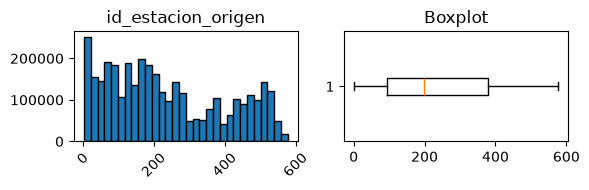

/var/folders/b0/rjcwq48561q3hnwzmfnnzrrc0000gn/T/ipykernel_1774/399506197.py:13: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(df[columna], vert=False)


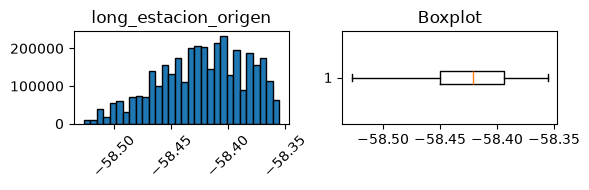

/var/folders/b0/rjcwq48561q3hnwzmfnnzrrc0000gn/T/ipykernel_1774/399506197.py:13: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(df[columna], vert=False)


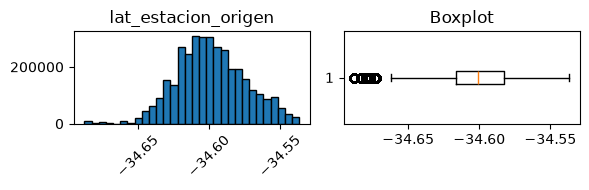

/var/folders/b0/rjcwq48561q3hnwzmfnnzrrc0000gn/T/ipykernel_1774/399506197.py:13: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(df[columna], vert=False)


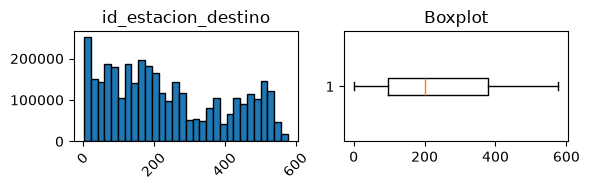

/var/folders/b0/rjcwq48561q3hnwzmfnnzrrc0000gn/T/ipykernel_1774/399506197.py:13: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(df[columna], vert=False)


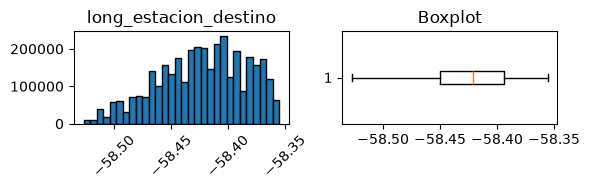

/var/folders/b0/rjcwq48561q3hnwzmfnnzrrc0000gn/T/ipykernel_1774/399506197.py:13: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(df[columna], vert=False)


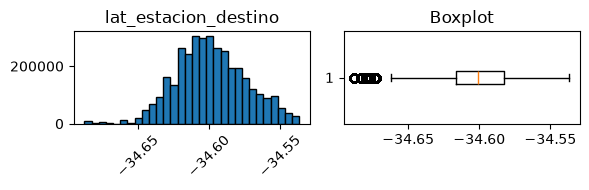

/var/folders/b0/rjcwq48561q3hnwzmfnnzrrc0000gn/T/ipykernel_1774/399506197.py:13: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(df[columna], vert=False)


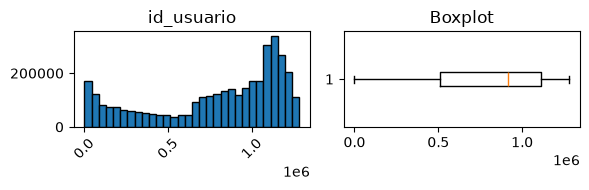

In [39]:
columnas = df.select_dtypes(include=np.number).columns

for columna in columnas:
    fig, ax = plt.subplots(1, 2, figsize=(6, 2))

    ax[0].hist(df[columna], bins=30, edgecolor='black')   #df[columna].dropna() si tuviera na
    ax[0].set_title(columna)
    ax[0].tick_params(axis='x', rotation=45)

    ax[1].boxplot(df[columna], vert=False)
    ax[1].set_title('Boxplot')

    plt.tight_layout()
    plt.show()

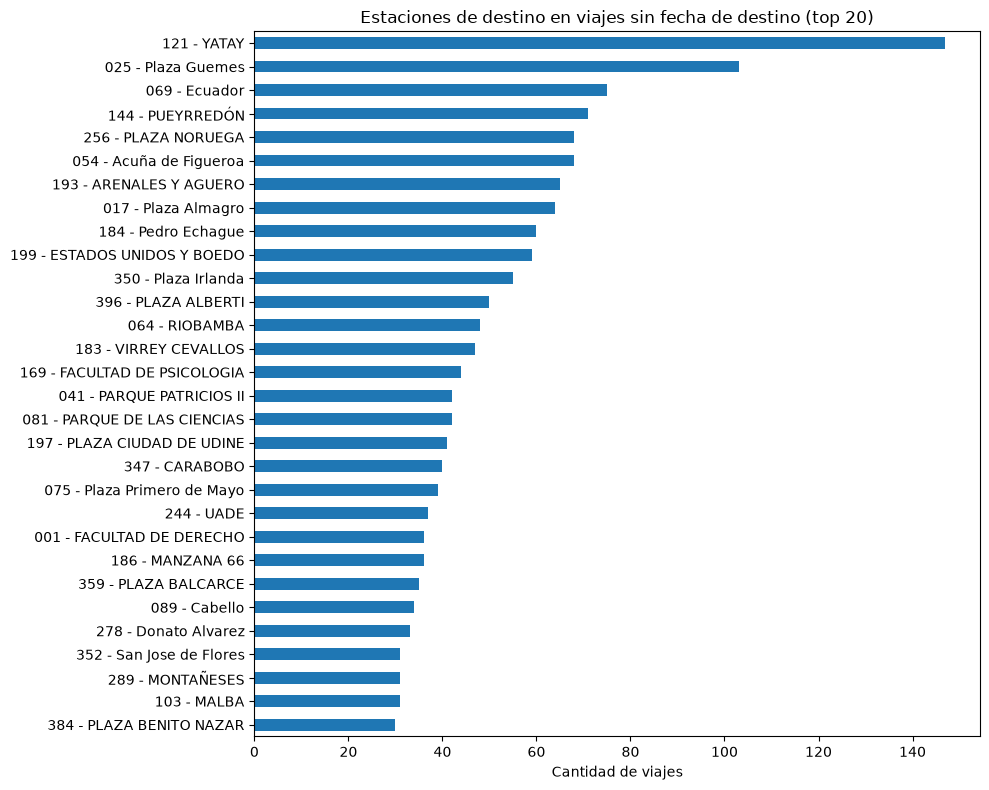

In [53]:
import matplotlib.pyplot as plt

falta = df['fecha_destino_recorrido'].isna()

conteo = (df.loc[falta, 'nombre_estacion_destino']
            .fillna('Sin estación')
            .value_counts()
            .head(30))

conteo.sort_values().plot.barh(figsize=(10, 8))
plt.title('Estaciones de destino en viajes sin fecha de destino (top 20)')
plt.xlabel('Cantidad de viajes')
plt.ylabel('')
plt.tight_layout()
plt.show()

                   count         mean          std  min    25%    50%     75%  \
fecha_destino                                                                   
Con fecha      3555904.0  1276.038216  9588.689485  0.0  494.0  882.0  1474.0   
Nula              3379.0     0.000000     0.000000  0.0    0.0    0.0     0.0   

                     max  
fecha_destino             
Con fecha      2571165.0  
Nula                 0.0  


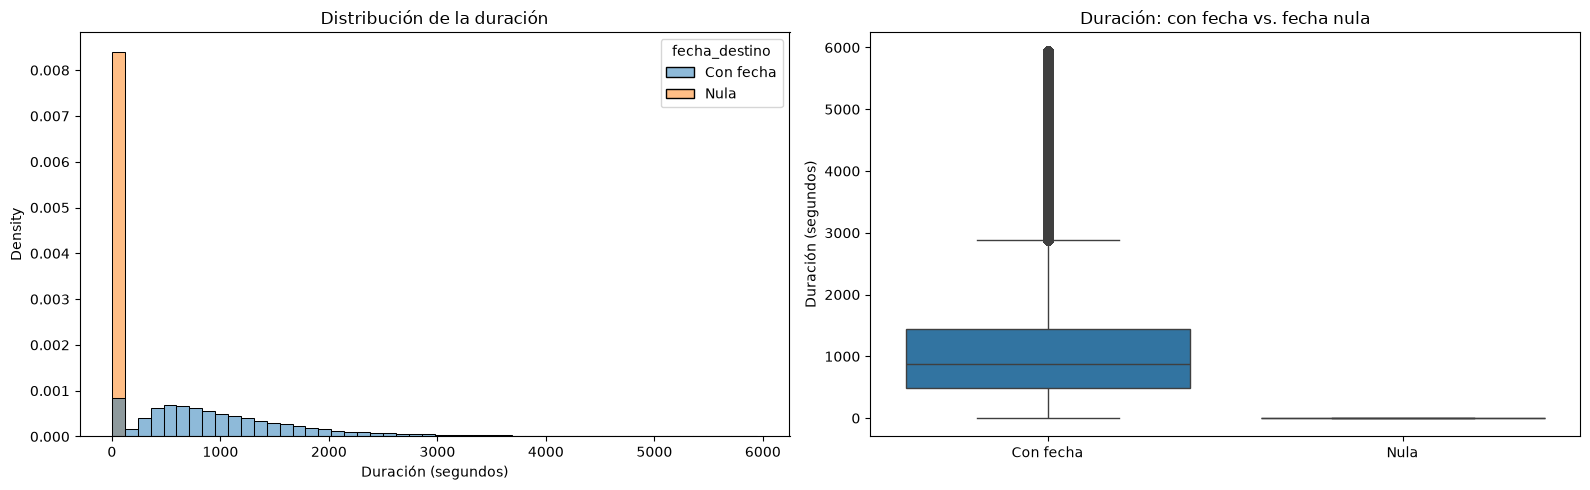

In [55]:

aux = df[['duracion_recorrido']].copy()
aux['fecha_destino'] = (df['fecha_destino_recorrido'].isna()
                          .map({True: 'Nula', False: 'Con fecha'}))

# resumen numérico de cada grupo
print(aux.groupby('fecha_destino')['duracion_recorrido'].describe())

# solo para graficar: saco el 1% más largo para que los extremos no aplasten todo
limite = aux['duracion_recorrido'].quantile(0.99)
graf = aux[aux['duracion_recorrido'] <= limite]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(data=graf, x='duracion_recorrido', hue='fecha_destino',
             stat='density', common_norm=False, bins=50, ax=axes[0])
axes[0].set_title('Distribución de la duración')
axes[0].set_xlabel('Duración (segundos)')

sns.boxplot(data=graf, x='fecha_destino', y='duracion_recorrido', ax=axes[1])
axes[1].set_title('Duración: con fecha vs. fecha nula')
axes[1].set_xlabel('')
axes[1].set_ylabel('Duración (segundos)')

plt.tight_layout()
plt.show()

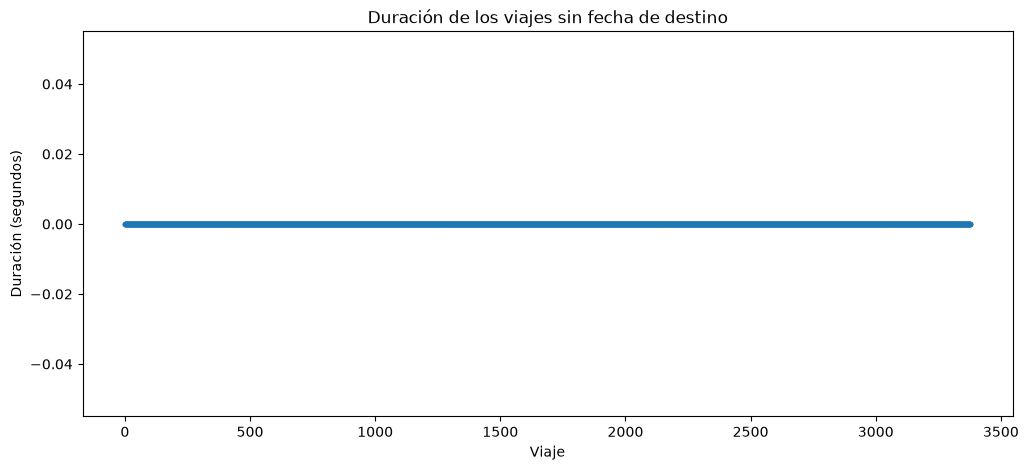

In [56]:
import matplotlib.pyplot as plt

falta = df['fecha_destino_recorrido'].isna()
dur = df.loc[falta, 'duracion_recorrido']

plt.figure(figsize=(12, 5))
plt.plot(dur.values, 'o', markersize=3)
plt.title('Duración de los viajes sin fecha de destino')
plt.xlabel('Viaje')
plt.ylabel('Duración (segundos)')
plt.show()

In [57]:
mismo = df['id_estacion_origen'] == df['id_estacion_destino']
print('Viajes con origen = destino:', mismo.sum(), f'({mismo.mean()*100:.2f}%)')

Viajes con origen = destino: 479327 (13.47%)


In [58]:
filtro = df['fecha_destino_recorrido'].notna() & (df['duracion_recorrido'] == 0)

print('Cantidad:', filtro.sum())
df.loc[filtro, ['id_recorrido', 'fecha_origen_recorrido', 'fecha_destino_recorrido',
                'id_estacion_origen', 'id_estacion_destino', 'duracion_recorrido']]

Cantidad: 34239


,id_recorrido,fecha_origen_recorrido,fecha_destino_recorrido,id_estacion_origen,id_estacion_destino,duracion_recorrido
2,20429936,2024-01-23 20:06:22,2024-01-23 20:06:22,467,6,0
3,20429976,2024-01-23 20:08:17,2024-01-23 20:08:17,382,460,0
20,20420562,2024-01-23 08:58:10,2024-01-23 08:58:10,212,277,0
41,20428071,2024-01-23 18:28:44,2024-01-23 18:28:44,130,128,0
53,20425872,2024-01-23 16:36:32,2024-01-23 16:36:32,6,29,0
...,...,...,...,...,...,...
3558644,21526490,2024-04-25 20:06:33,2024-04-25 20:06:33,33,174,0
3558693,21523107,2024-04-25 15:15:28,2024-04-25 15:15:28,275,83,0
3558885,21524511,2024-04-25 16:52:23,2024-04-25 16:52:23,458,371,0
3559165,21520376,2024-04-25 09:27:42,2024-04-25 09:27:42,271,504,0


In [62]:
filtro = df['fecha_destino_recorrido'].isna() 
print('Cantidad:', filtro.sum())
df.loc[filtro, ['id_recorrido', 'fecha_origen_recorrido', 'fecha_destino_recorrido',
                'id_estacion_origen', 'id_estacion_destino', 'duracion_recorrido',]]

Cantidad: 3379


,id_recorrido,fecha_origen_recorrido,fecha_destino_recorrido,id_estacion_origen,id_estacion_destino,duracion_recorrido
63800,24502775,2024-12-31 20:34:50,NaN,324,553,0
63801,24502746,2024-12-31 20:25:28,NaN,369,553,0
64730,24493951,2024-12-30 21:08:03,NaN,418,418,0
64741,24493039,2024-12-30 19:55:50,NaN,385,498,0
64748,24493560,2024-12-30 20:33:54,NaN,14,387,0
...,...,...,...,...,...,...
3080864,23777811,2024-11-07 18:49:06,NaN,131,86,0
3080869,23776961,2024-11-07 18:17:15,NaN,6,433,0
3080870,23775753,2024-11-07 17:30:26,NaN,73,433,0
3080872,23778518,2024-11-07 19:23:23,NaN,65,54,0


In [61]:


# 1. Definimos las dos condiciones de filtro
condicion_nulos = df['fecha_destino_recorrido'].isnull()
condicion_iguales = df['fecha_destino_recorrido'] == df['fecha_origen_recorrido']

# 2. Definimos las columnas a conservar (sumé las fechas para tu revisión)
columnas_interes = [
    'nombre_estacion_origen', 
    'nombre_estacion_destino', 
    'duracion_recorrido',
    'fecha_origen_recorrido',
    'fecha_destino_recorrido'
]

# 3. Filtramos uniendo las condiciones con "|" (OR) y creamos el nuevo dataframe
df_viajes_inconclusos = df[condicion_nulos | condicion_iguales][columnas_interes].copy()

# 4. Revisamos la cantidad total y las primeras 10 filas
print(f"Total de registros sospechosos: {len(df_viajes_inconclusos)}")
print(df_viajes_inconclusos.head(10))

Total de registros sospechosos: 37626
                       nombre_estacion_origen  nombre_estacion_destino  \
2                          328 - SARMIENTO II      006 - Parque Lezama   
3                              204 - Biarritz   133 - BEIRO Y SEGUROLA   
20                              129 - Velasco      292 - PLAZA BOLIVIA   
41                            130 - RETIRO II    128 - PARQUE DEL BAJO   
53                        006 - Parque Lezama  029 - Parque Centenario   
70                  290 - Club Excursionistas      292 - PLAZA BOLIVIA   
110                    200 - AUSTRIA Y FRENCH         112 - 9 de Julio   
155  126 - Ministerio de Justicia y Seguridad  196 - HOSPITAL ARGERICH   
169                270 - PLAZA DEL ANGEL GRIS           285 - ESPINOSA   
391                  073 - Ruy Díaz de Guzmán     156 - Plaza Alemania   

     duracion_recorrido fecha_origen_recorrido fecha_destino_recorrido  
2                     0    2024-01-23 20:06:22     2024-01-23 20:06:22  
3

In [72]:
origen = pd.to_datetime(df['fecha_origen_recorrido'])
destino = pd.to_datetime(df['fecha_destino_recorrido'])

filtro = (df['duracion_recorrido'] == 0) & destino.isna()

print('Cantidad:', filtro.sum())
df.loc[filtro, ['id_recorrido', 'fecha_origen_recorrido', 'fecha_destino_recorrido',
                'duracion_recorrido', 'id_estacion_origen', 'id_estacion_destino']] \
  .assign(dur_calculada_seg=(destino - origen).dt.total_seconds())

Cantidad: 3379


,id_recorrido,fecha_origen_recorrido,fecha_destino_recorrido,duracion_recorrido,id_estacion_origen,id_estacion_destino,dur_calculada_seg
63800,24502775,2024-12-31 20:34:50,NaT,0,324,553,NaN
63801,24502746,2024-12-31 20:25:28,NaT,0,369,553,NaN
64730,24493951,2024-12-30 21:08:03,NaT,0,418,418,NaN
64741,24493039,2024-12-30 19:55:50,NaT,0,385,498,NaN
64748,24493560,2024-12-30 20:33:54,NaT,0,14,387,NaN
...,...,...,...,...,...,...,...
3080864,23777811,2024-11-07 18:49:06,NaT,0,131,86,NaN
3080869,23776961,2024-11-07 18:17:15,NaT,0,6,433,NaN
3080870,23775753,2024-11-07 17:30:26,NaT,0,73,433,NaN
3080872,23778518,2024-11-07 19:23:23,NaT,0,65,54,NaN


In [78]:
origen = pd.to_datetime(df['fecha_origen_recorrido'])
destino = pd.to_datetime(df['fecha_destino_recorrido'])

filtro = ((df['duracion_recorrido'] == 0) & (origen == destino)
         & (df['id_estacion_origen'] != df['id_estacion_destino']))

print('Cantidad:', filtro.sum())
df.loc[filtro, ['id_recorrido', 'fecha_origen_recorrido', 'fecha_destino_recorrido',
                'duracion_recorrido', 'id_estacion_origen', 'id_estacion_destino']] \
  .assign(dur_calculada_seg=(destino - origen).dt.total_seconds())

Cantidad: 28120


,id_recorrido,fecha_origen_recorrido,fecha_destino_recorrido,duracion_recorrido,id_estacion_origen,id_estacion_destino,dur_calculada_seg
2,20429936,2024-01-23 20:06:22,2024-01-23 20:06:22,0,467,6,0.0
3,20429976,2024-01-23 20:08:17,2024-01-23 20:08:17,0,382,460,0.0
20,20420562,2024-01-23 08:58:10,2024-01-23 08:58:10,0,212,277,0.0
41,20428071,2024-01-23 18:28:44,2024-01-23 18:28:44,0,130,128,0.0
53,20425872,2024-01-23 16:36:32,2024-01-23 16:36:32,0,6,29,0.0
...,...,...,...,...,...,...,...
3558644,21526490,2024-04-25 20:06:33,2024-04-25 20:06:33,0,33,174,0.0
3558693,21523107,2024-04-25 15:15:28,2024-04-25 15:15:28,0,275,83,0.0
3558885,21524511,2024-04-25 16:52:23,2024-04-25 16:52:23,0,458,371,0.0
3559165,21520376,2024-04-25 09:27:42,2024-04-25 09:27:42,0,271,504,0.0


In [68]:
#paso a datetime ambas columnas
df['fecha_origen_recorrido'] = pd.to_datetime(df['fecha_origen_recorrido'])
df['fecha_destino_recorrido'] = pd.to_datetime(df['fecha_destino_recorrido'])

In [ ]:
#conclusiones:
#hay 3379 null en fecha destino. 
#todos los registros que tienen fecha destino null tiene duracion=0. 
#hay 8 registros que tienen duracion>0 y fechaorigen=fechadestino
#hay 34239 registros que tienen duracion==0 y fechaorigen=fechadestino 
#hay 6119 dentro de los 34239 que tienen duracion 0, fecha origen=fecha destino y ademas idestacion origen=id destino.

In [74]:
origen = pd.to_datetime(df['fecha_origen_recorrido'])
destino = pd.to_datetime(df['fecha_destino_recorrido'])

filtro = ((df['duracion_recorrido'] == 0)
          & (origen == destino)
          & (df['id_estacion_origen'] == df['id_estacion_destino']))

print('Cantidad:', filtro.sum())
df.loc[filtro, ['id_recorrido', 'fecha_origen_recorrido', 'fecha_destino_recorrido',
                'duracion_recorrido', 'id_estacion_origen', 'id_estacion_destino']] \
  .assign(dur_calculada_seg=(destino - origen).dt.total_seconds())

Cantidad: 6119


,id_recorrido,fecha_origen_recorrido,fecha_destino_recorrido,duracion_recorrido,id_estacion_origen,id_estacion_destino,dur_calculada_seg
416,20411915,2024-01-22 17:19:51,2024-01-22 17:19:51,0,277,277,0.0
501,20405580,2024-01-22 08:15:48,2024-01-22 08:15:48,0,8,8,0.0
1438,23574911,2024-10-24 22:02:39,2024-10-24 22:02:39,0,70,70,0.0
1990,23568281,2024-10-24 10:11:25,2024-10-24 10:11:25,0,508,508,0.0
2325,23563362,2024-10-23 21:26:25,2024-10-23 21:26:25,0,519,519,0.0
...,...,...,...,...,...,...,...
3554247,21510424,2024-04-24 13:41:18,2024-04-24 13:41:18,0,65,65,0.0
3554322,21509761,2024-04-24 13:07:43,2024-04-24 13:07:43,0,504,504,0.0
3554834,21506460,2024-04-24 08:26:32,2024-04-24 08:26:32,0,5,5,0.0
3556963,21502496,2024-04-23 20:01:50,2024-04-23 20:01:50,0,75,75,0.0


count    3.559283e+06
mean     2.124711e+01
std      1.597370e+02
min      0.000000e+00
25%      8.216667e+00
50%      1.468333e+01
75%      2.456667e+01
max      4.285275e+04
Name: duracion_recorrido, dtype: float64
Asimetría: 156.2195062722179


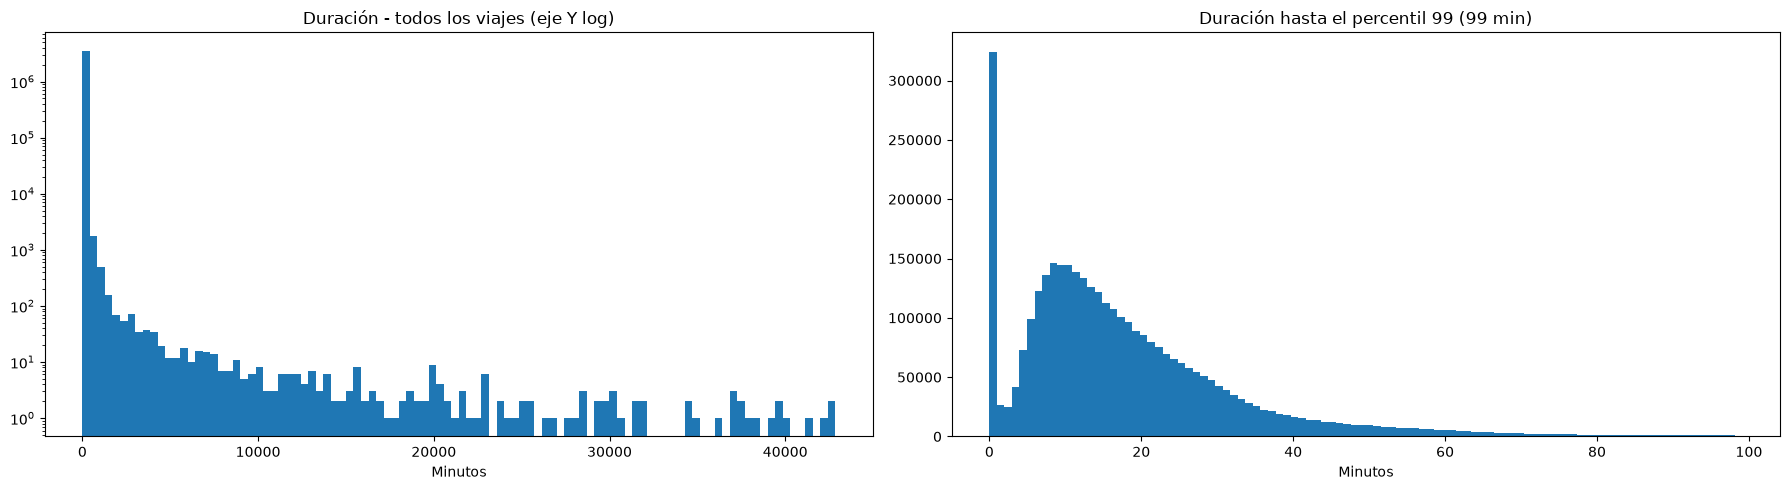

In [81]:

dur = df['duracion_recorrido'] / 60   # minutos

print(dur.describe())
print('Asimetría:', dur.skew())

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# 1. Todos los viajes, con eje Y logarítmico para que se vea la cola
axes[0].hist(dur, bins=100)
axes[0].set_yscale('log')
axes[0].set_title('Duración - todos los viajes (eje Y log)')
axes[0].set_xlabel('Minutos')

# 2. Sin el 1% más largo, para ver la forma de la mayoría
p99 = dur.quantile(0.99)
axes[1].hist(dur[dur <= p99], bins=100)
axes[1].set_title(f'Duración hasta el percentil 99 ({p99:.0f} min)')
axes[1].set_xlabel('Minutos')

plt.tight_layout()
plt.show()

dia_semana
Lunes        16.5
Martes       17.7
Miércoles    17.5
Jueves       18.0
Viernes      17.0
Sábado        6.7
Domingo       6.5
Name: proportion, dtype: float64


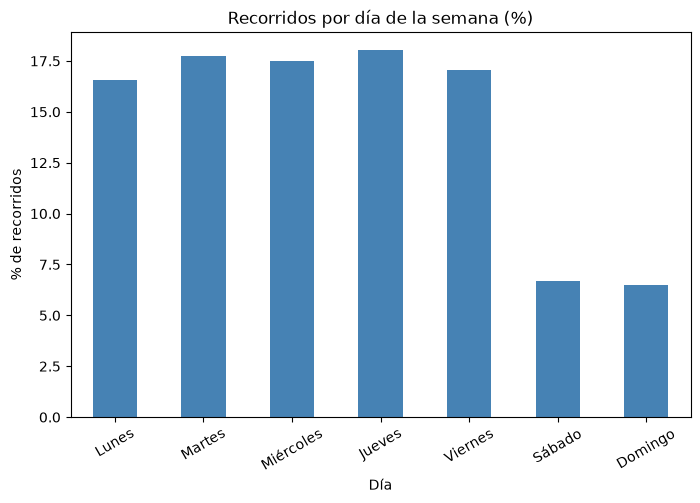

In [82]:
df['hora'] = df['fecha_origen_recorrido'].dt.hour
df['dia_semana'] = df['fecha_origen_recorrido'].dt.day_name()

# Traducción a español (day_name() devuelve nombres en inglés)
traduccion_dias = {
    'Monday': 'Lunes', 'Tuesday': 'Martes', 'Wednesday': 'Miércoles',
    'Thursday': 'Jueves', 'Friday': 'Viernes', 'Saturday': 'Sábado', 'Sunday': 'Domingo'
}
df['dia_semana'] = df['dia_semana'].map(traduccion_dias)

orden_dias = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']

# % de recorridos por día de la semana
dia_pct = df['dia_semana'].value_counts(normalize=True) * 100
dia_pct = dia_pct.reindex(orden_dias)
print(dia_pct.round(1))

plt.figure(figsize=(8,5))
dia_pct.plot(kind='bar', color='steelblue')
plt.title('Recorridos por día de la semana (%)')
plt.xlabel('Día')
plt.ylabel('% de recorridos')
plt.xticks(rotation=30)
plt.show()

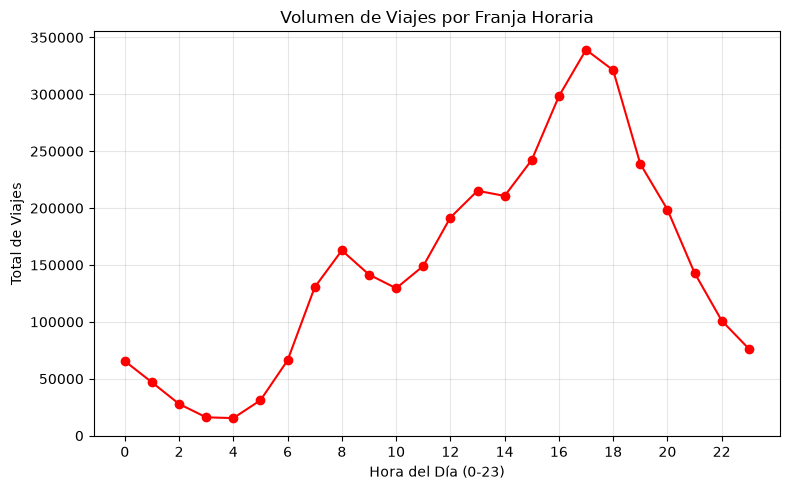

In [83]:
df['hora'] = df['fecha_origen_recorrido'].dt.hour

viajes_por_hora = df['hora'].value_counts().sort_index()

plt.figure(figsize=(8,5))
viajes_por_hora.plot(kind='line', marker='o', color='red')
plt.title('Volumen de Viajes por Franja Horaria')
plt.xlabel('Hora del Día (0-23)')
plt.ylabel('Total de Viajes')
plt.xticks(range(0,24,2))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

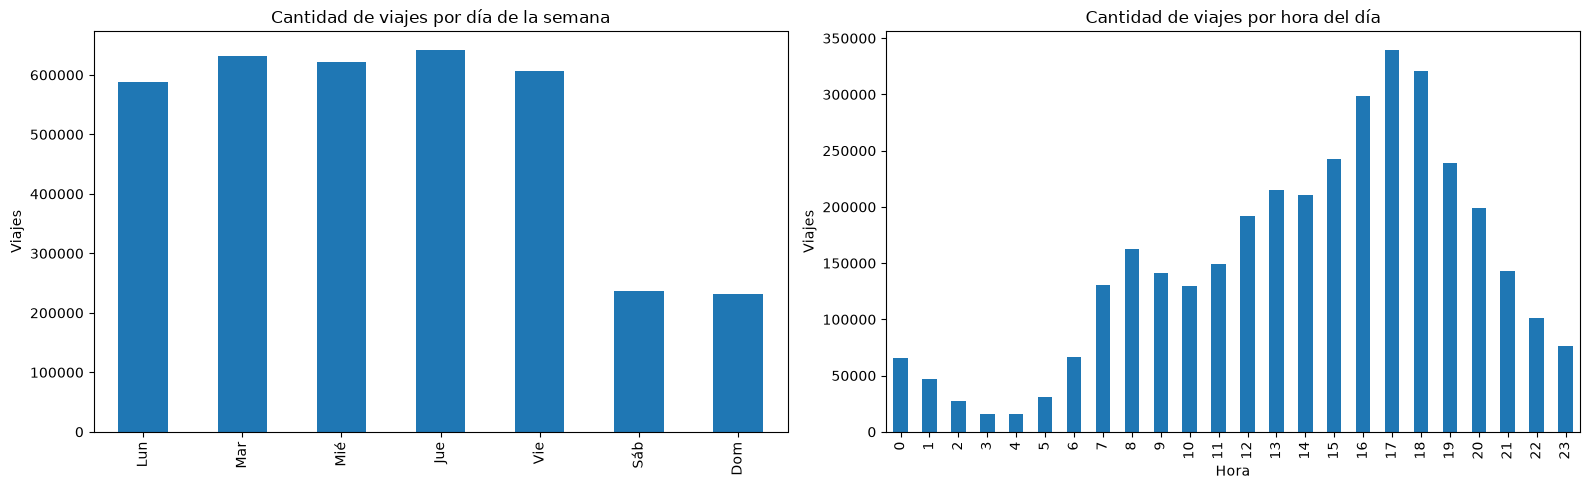

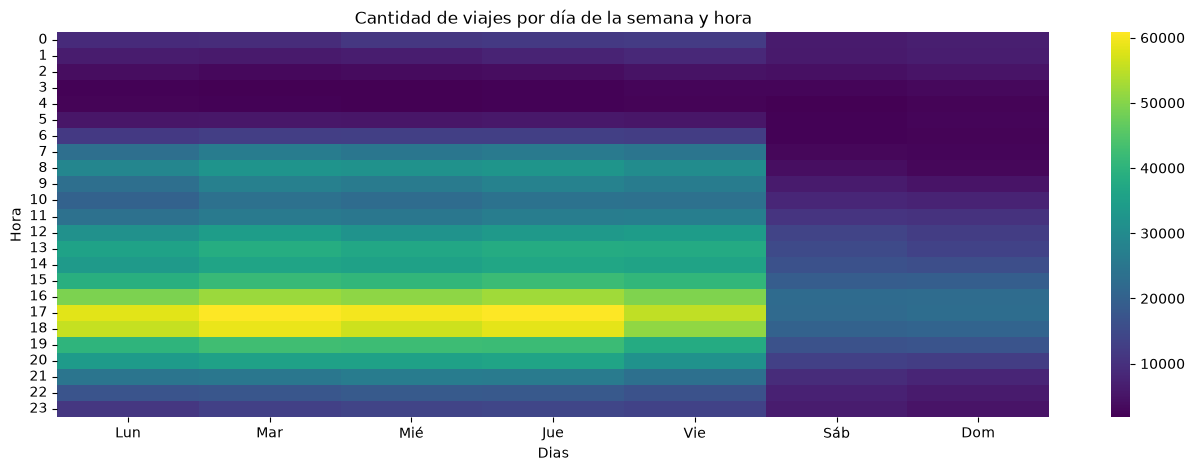

In [88]:
fecha = pd.to_datetime(df['fecha_origen_recorrido'])
dias = {0: 'Lun', 1: 'Mar', 2: 'Mié', 3: 'Jue', 4: 'Vie', 5: 'Sáb', 6: 'Dom'}

# 1. Barras: por día y por hora
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

fecha.dt.dayofweek.value_counts().sort_index().rename(index=dias).plot.bar(ax=axes[0])
axes[0].set_title('Cantidad de viajes por día de la semana')
axes[0].set_xlabel('')
axes[0].set_ylabel('Viajes')

fecha.dt.hour.value_counts().sort_index().plot.bar(ax=axes[1])
axes[1].set_title('Cantidad de viajes por hora del día')
axes[1].set_xlabel('Hora')
axes[1].set_ylabel('Viajes')

plt.tight_layout()
plt.show()

# 2. Mapa de calor: día x hora
tabla = pd.crosstab(fecha.dt.hour,fecha.dt.dayofweek).rename(columns=dias)

plt.figure(figsize=(16, 5))
sns.heatmap(tabla, cmap='viridis')
plt.title('Cantidad de viajes por día de la semana y hora')
plt.xlabel('Dias')
plt.ylabel('Hora')
plt.show()

Podemos observar que los dias de semana a las 17hs aprox hay mayor cantidad de viajes.
A las 8am hay un pequeño pico y la frecuencia de uso los fines de semana es muy baja, independientemente del horario. Apenas se nota un aumento del uso en la tarde. 


 # titulo 
 ## titulo2 
 ### titulo 

Regresión: Duración del viaje Ecobici

Variable objetivo (y):

duracion_minutos o duracion_segundos

Features candidatas (X):

Espaciales: distancia (lat/lon origen-destino), zona origen, zona destino
Temporales: hora, día semana, mes, es_fin_semana, es_horario_pico
usaurio=genero
Desafíos esperados:

Outliers: algunos viajes anormalmente largos/cortos
Distribución asimétrica (cola derecha)
No linealidad: relación distancia-duración no perfecta

Escenario: el usuario retira la bici, indica a qué estación va y se predice cuánto va a durar el viaje.
Tipo: regresión.
Target: duración en minutos.
Features: las de la lista.
Excluidas por leakage: las columnas que no se conocen al momento de retirar la bici, con el porqué.


Sacariamos los datos de fecha destion null y duracion recorrido==0. 
Faltaria justificar porque. 
Realizar una limpieza general del dataset, eliminando o corrigiendo datos
inconsistentes o irrelevantes.


           viajes      %
genero                  
MALE      2147720  60.34
FEMALE    1133660  31.85
OTHER      265957   7.47
Sin dato    11946   0.34


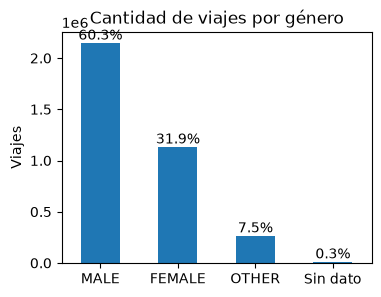

In [97]:
conteo = df['genero'].fillna('Sin dato').value_counts()
pct = conteo / conteo.sum() * 100

print(pd.DataFrame({'viajes': conteo, '%': pct.round(2)}))

ax = conteo.plot.bar(figsize=(4, 3))
ax.bar_label(ax.containers[0], labels=[f'{p:.1f}%' for p in pct])
plt.title('Cantidad de viajes por género')
plt.xlabel('')
plt.ylabel('Viajes')
plt.xticks(rotation=0)
plt.show()

Vamos a pasar los de generos=nulos

In [94]:
df[df.genero.isna()]

,id_recorrido,duracion_recorrido,fecha_origen_recorrido,id_estacion_origen,nombre_estacion_origen,direccion_estacion_origen,long_estacion_origen,lat_estacion_origen,fecha_destino_recorrido,id_estacion_destino,nombre_estacion_destino,direccion_estacion_destino,long_estacion_destino,lat_estacion_destino,id_usuario,modelo_bicicleta,genero,hora,dia_semana
242,20421678,1071,2024-01-23 10:36:25,23,023 - Suipacha,Suipacha & Viamonte,-58.379836,-34.600139,2024-01-23 10:54:16,172,172 - BRASIL,BRASIL&DEFENSA,-58.371082,-34.625426,22682.0,FIT,NaN,10,Martes
898,20430626,3011,2024-01-23 20:48:23,416,257 - Plaza Francisco Ramirez,"2700 Pedraza, Manuela",-58.469133,-34.553262,2024-01-23 21:38:34,318,285 - ESPINOSA,1785 Espinosa,-58.457317,-34.603936,20757.0,FIT,NaN,20,Martes
899,20428035,2754,2024-01-23 18:26:57,318,285 - ESPINOSA,1785 Espinosa,-58.457317,-34.603936,2024-01-23 19:12:51,416,257 - Plaza Francisco Ramirez,"2700 Pedraza, Manuela",-58.469133,-34.553262,20757.0,FIT,NaN,18,Martes
900,20421780,639,2024-01-23 10:47:46,242,103 - MALBA,Av. Pres. Figueroa Alcorta 3451,-58.403984,-34.576949,2024-01-23 10:58:25,14,014 - Pacifico,"Santa Fe Av. & Bullrich, Int. Av.",-58.426387,-34.577424,20753.0,ICONIC,NaN,10,Martes
1020,20422378,710,2024-01-23 11:43:34,59,018 - Independencia,Idependencia y Bernardo de Irigoyen,-58.380565,-34.617654,2024-01-23 11:55:24,83,083 - Paraná,1590 Lavalle,-58.389373,-34.603269,19535.0,FIT,NaN,11,Martes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3556861,21498506,1288,2024-04-23 16:51:54,150,150 - RODRIGO BUENO,Av. España 2200,-58.355465,-34.618755,2024-04-23 17:13:22,35,035 - INGENIERO BUTTY,Ing. E. Butty 291,-58.371847,-34.596425,22645.0,ICONIC,NaN,16,Martes
3557009,21492658,619,2024-04-23 11:18:38,466,333 - PARQUE DE LA ESTACIÓN,Dr. Tomás Manuel de Anchorena 170,-58.411840,-34.608096,2024-04-23 11:28:57,66,066 - Billinghurst,3508 Carcova,-58.413871,-34.594547,20671.0,FIT,NaN,11,Martes
3557679,21537441,150,2024-04-27 09:58:42,80,080 - VALLE,Valle 486,-58.434123,-34.624581,2024-04-27 10:01:12,80,080 - VALLE,Valle 486,-58.434123,-34.624581,20057.0,FIT,NaN,9,Sábado
3558079,21533326,1406,2024-04-26 18:03:33,189,189 - POSADAS,1350 Posadas,-58.385211,-34.588689,2024-04-26 18:26:59,66,066 - Billinghurst,3508 Carcova,-58.413871,-34.594547,20671.0,FIT,NaN,18,Viernes


Quitamos los fecha destino null. la razon es porque tienen id de destino pero no una fecha, probablemente sea MCAR por fallas del sistema. como la falta es al azar, sacarlas no introduce sesgo.


Para genero, como el sistema propone male,female,other, podemos pensar que el sistema tuvo un error al captar el dato que ingreso el usuario. Como es un error totalmente aleatorio, podemos decir que es mcar y al ser 0.34% podriamos eliminar las filas. 

    

In [101]:
for col in df.select_dtypes(include='number'):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    outliers = df[ (df[col] < limite_inferior) | (df[col] > limite_superior) ]

    print(col, len(outliers))

id_recorrido 0
duracion_recorrido 197787
id_estacion_origen 0
long_estacion_origen 0
lat_estacion_origen 17843
id_estacion_destino 0
long_estacion_destino 0
lat_estacion_destino 19863
id_usuario 0
hora 65528
